In [2]:
# ==============================
# PHISHING DETECTION AI V2
# ==============================

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Model Saving
import pickle

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Graph Settings
plt.style.use("ggplot")
%matplotlib inline

In [3]:
df=pd.read_csv('phishing_site_urls.csv')

In [4]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [5]:
df.shape

(549346, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [7]:
df.isnull().sum()

URL      0
Label    0
dtype: int64

In [8]:
df.Label.value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [9]:
from nltk.tokenize import RegexpTokenizer

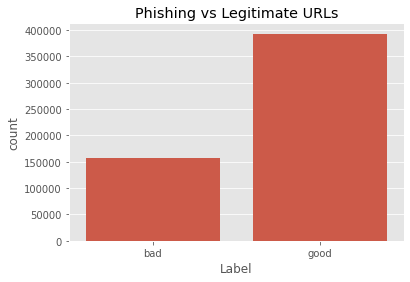

In [10]:
# Visualize Class Distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Label")

plt.title("Phishing vs Legitimate URLs")

plt.show()

In [11]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [12]:
# Create a backup of original dataset

data = df.copy()

print("Backup Created Successfully ✅")

Backup Created Successfully ✅


In [13]:
# Display column names

print(data.columns)

Index(['URL', 'Label'], dtype='object')


In [14]:
# URL Cleaning Function

def clean_url(url):

    # Convert to lowercase
    url = url.lower()

    # Remove http / https
    url = re.sub(r'https?://', '', url)

    # Remove www
    url = re.sub(r'www\.', '', url)

    # Remove extra spaces
    url = url.strip()

    return url

In [15]:
# Apply URL Cleaning

data["Clean_URL"] = data["URL"].apply(clean_url)

data[["URL","Clean_URL"]].head()

,URL,Clean_URL
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,nobell.it/70ffb52d079109dca5664cce6f317373782/...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,serviciosbys.com/paypal.cgi.bin.get-into.herf....
3,mail.printakid.com/www.online.americanexpress....,mail.printakid.com/online.americanexpress.com/...
4,thewhiskeydregs.com/wp-content/themes/widescre...,thewhiskeydregs.com/wp-content/themes/widescre...


In [16]:
# Compare Original and Clean URL

for i in range(5):
    print("Original :", data["URL"][i])
    print("Clean    :", data["Clean_URL"][i])
    print("-"*60)

Original : nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526
Clean    : nobell.it/70ffb52d079109dca5664cce6f317373782/login.skype.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526
------------------------------------------------------------
Original : www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home-customer&nav=1/loading.php
Clean    : dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home-customer&nav=1/loading.php
------------------------------------------------------------
Original : serviciosbys.com/paypal.cgi.bin.get-into.herf.secure.dispatch35463256rzr321654641dsf654321874/href/href/href/secure/center/update/limit/seccure/4d7a1ff5c55825a2e632a679c2fd5353/
Clean    : serviciosbys.com/paypa

In [17]:
# =====================================================
# FEATURE ENGINEERING
# =====================================================

def extract_features(url):

    features = {}

    # URL Length
    features["url_length"] = len(url)

    # Number of Dots
    features["dot_count"] = url.count('.')

    # Number of Hyphens
    features["hyphen_count"] = url.count('-')

    # Number of Underscores
    features["underscore_count"] = url.count('_')

    # Number of Slashes
    features["slash_count"] = url.count('/')

    # Number of Question Marks
    features["question_count"] = url.count('?')

    # Number of Equal Symbols
    features["equal_count"] = url.count('=')

    # Number of @ Symbols
    features["at_count"] = url.count('@')

    # Number of Digits
    features["digit_count"] = sum(c.isdigit() for c in url)

    return features

In [18]:
# Extract Features

feature_df = data["Clean_URL"].apply(extract_features)

feature_df = pd.DataFrame(feature_df.tolist())

feature_df.head()

,url_length,dot_count,hyphen_count,underscore_count,slash_count,question_count,equal_count,at_count,digit_count
0,225,6,4,4,10,1,4,0,58
1,77,4,2,1,4,0,2,0,1
2,177,7,1,0,11,0,0,0,47
3,56,5,0,0,2,0,0,0,0
4,116,1,1,0,10,1,0,0,21


In [19]:
# Merge Features

data = pd.concat([data, feature_df], axis=1)

data.head()

,URL,Label,Clean_URL,url_length,dot_count,hyphen_count,underscore_count,slash_count,question_count,equal_count,at_count,digit_count
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,nobell.it/70ffb52d079109dca5664cce6f317373782/...,225,6,4,4,10,1,4,0,58
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,77,4,2,1,4,0,2,0,1
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,serviciosbys.com/paypal.cgi.bin.get-into.herf....,177,7,1,0,11,0,0,0,47
3,mail.printakid.com/www.online.americanexpress....,bad,mail.printakid.com/online.americanexpress.com/...,56,5,0,0,2,0,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,thewhiskeydregs.com/wp-content/themes/widescre...,116,1,1,0,10,1,0,0,21


In [20]:
# Check Newly Created Features

data.columns

Index(['URL', 'Label', 'Clean_URL', 'url_length', 'dot_count', 'hyphen_count',
       'underscore_count', 'slash_count', 'question_count', 'equal_count',
       'at_count', 'digit_count'],
      dtype='object')

In [21]:
# Feature Statistics

data.describe()

,url_length,dot_count,hyphen_count,underscore_count,slash_count,question_count,equal_count,at_count,digit_count
count,549346.000000,549346.000000,549346.000000,549346.000000,549346.000000,549346.000000,549346.000000,549346.000000,549346.000000
mean,50.329688,1.964784,1.126461,0.390845,2.440547,0.161390,0.278629,0.003877,4.769573
std,44.330823,1.452470,2.424343,1.317131,1.582715,0.512545,0.956683,0.068101,11.572873
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,40.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
75%,59.000000,2.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,6.000000
max,2307.000000,37.000000,42.000000,200.000000,34.000000,166.000000,34.000000,10.000000,545.000000


In [22]:
# =====================================================
# ADVANCED FEATURE ENGINEERING
# =====================================================

# HTTPS Feature
data["has_https"] = data["URL"].str.startswith("https").astype(int)

# www Feature
data["has_www"] = data["URL"].str.contains("www").astype(int)

# IP Address Detection
ip_pattern = r'((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)(\.|$)){4}'

data["has_ip"] = data["URL"].apply(lambda x: 1 if re.search(ip_pattern, x) else 0)

In [23]:
# Suspicious Keywords

keywords = [
    "login",
    "verify",
    "bank",
    "secure",
    "account",
    "update",
    "paypal",
    "signin",
    "confirm",
    "password"
]

for word in keywords:
    data[f"contains_{word}"] = data["Clean_URL"].str.contains(word).astype(int)

print("Keyword Features Added Successfully ✅")

Keyword Features Added Successfully ✅


In [24]:
# URL Shortener Detection

shorteners = [
    "bit.ly",
    "tinyurl",
    "goo.gl",
    "t.co",
    "ow.ly",
    "buff.ly",
    "is.gd",
    "rebrand.ly"
]

data["is_shortened"] = data["Clean_URL"].apply(
    lambda x: any(short in x for short in shorteners)
).astype(int)

In [25]:
# Special Character Count

special_chars = ['@', '?', '-', '=', '.', '#', '%', '+', '$', '!']

data["special_char_count"] = data["Clean_URL"].apply(
    lambda x: sum(x.count(char) for char in special_chars)
)

In [26]:
# Domain Length

def domain_length(url):
    return len(url.split("/")[0])

data["domain_length"] = data["Clean_URL"].apply(domain_length)

In [27]:
# Display Engineered Features

data.head()

,URL,Label,Clean_URL,url_length,dot_count,hyphen_count,underscore_count,slash_count,question_count,equal_count,...,contains_secure,contains_account,contains_update,contains_paypal,contains_signin,contains_confirm,contains_password,is_shortened,special_char_count,domain_length
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,nobell.it/70ffb52d079109dca5664cce6f317373782/...,225,6,4,4,10,1,4,...,0,0,0,0,0,0,0,0,15,9
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_...,77,4,2,1,4,0,2,...,0,0,0,1,0,0,0,0,8,11
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,serviciosbys.com/paypal.cgi.bin.get-into.herf....,177,7,1,0,11,0,0,...,1,0,1,1,0,0,0,0,8,16
3,mail.printakid.com/www.online.americanexpress....,bad,mail.printakid.com/online.americanexpress.com/...,56,5,0,0,2,0,0,...,0,0,0,0,0,0,0,0,5,18
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,thewhiskeydregs.com/wp-content/themes/widescre...,116,1,1,0,10,1,0,...,0,0,0,0,0,0,0,0,3,19


In [28]:
# TF-IDF Vectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_text = tfidf.fit_transform(data["Clean_URL"])

In [29]:
print(X_text.shape)

(549346, 5000)


In [30]:
# Labels

y = data["Label"]

In [31]:
# Encode Labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [32]:
print(encoder.classes_)

['bad' 'good']


In [33]:
# Manual Features

manual_features = data.drop(columns=["URL", "Clean_URL", "Label"])

manual_features.head()

,url_length,dot_count,hyphen_count,underscore_count,slash_count,question_count,equal_count,at_count,digit_count,has_https,...,contains_secure,contains_account,contains_update,contains_paypal,contains_signin,contains_confirm,contains_password,is_shortened,special_char_count,domain_length
0,225,6,4,4,10,1,4,0,58,0,...,0,0,0,0,0,0,0,0,15,9
1,77,4,2,1,4,0,2,0,1,0,...,0,0,0,1,0,0,0,0,8,11
2,177,7,1,0,11,0,0,0,47,0,...,1,0,1,1,0,0,0,0,8,16
3,56,5,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,5,18
4,116,1,1,0,10,1,0,0,21,0,...,0,0,0,0,0,0,0,0,3,19


In [34]:
print(manual_features.shape)

(549346, 25)


In [35]:
from scipy.sparse import hstack

X = hstack([X_text, manual_features.values])

print("Final Feature Matrix Shape :", X.shape)

Final Feature Matrix Shape : (549346, 5025)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print(X_train.shape)
print(X_test.shape)

(439476, 5025)
(109870, 5025)


In [38]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

models = {

    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Linear SVM": LinearSVC(
        random_state=42
    )

}

results = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

    print(f"Accuracy : {acc:.4f}")

print(results)


Training Naive Bayes...


Accuracy : 0.8938

Training Logistic Regression...
Accuracy : 0.9290

Training Linear SVM...
Accuracy : 0.9367
{'Naive Bayes': 0.893774460726313, 'Logistic Regression': 0.9289706016200965, 'Linear SVM': 0.9367252207153909}


In [39]:
final_model = LinearSVC(
    C=1,
    random_state=42
)

final_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [40]:
pred = final_model.predict(X_test)

In [41]:
print("Accuracy :", accuracy_score(y_test, pred))

Accuracy : 0.9367252207153909


In [42]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.83      0.88     31285
           1       0.93      0.98      0.96     78585

    accuracy                           0.94    109870
   macro avg       0.94      0.90      0.92    109870
weighted avg       0.94      0.94      0.94    109870



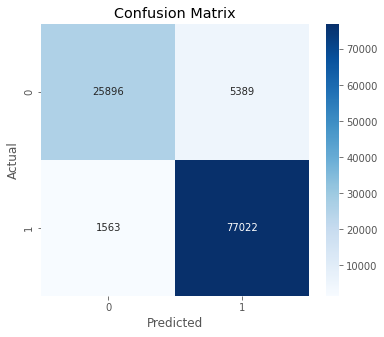

In [43]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [44]:
import pickle

pickle.dump(
    final_model,
    open("phishing_model.pkl","wb")
)

In [45]:
pickle.dump(
    tfidf,
    open("tfidf_vectorizer.pkl","wb")
)

In [46]:
print(X.shape)

(549346, 5025)


In [47]:
print(X_train.shape)

(439476, 5025)


In [48]:
print(type(X))

<class 'scipy.sparse._coo.coo_matrix'>


In [49]:
print(manual_features.columns.tolist())

['url_length', 'dot_count', 'hyphen_count', 'underscore_count', 'slash_count', 'question_count', 'equal_count', 'at_count', 'digit_count', 'has_https', 'has_www', 'has_ip', 'contains_login', 'contains_verify', 'contains_bank', 'contains_secure', 'contains_account', 'contains_update', 'contains_paypal', 'contains_signin', 'contains_confirm', 'contains_password', 'is_shortened', 'special_char_count', 'domain_length']


In [50]:
print(final_model.n_features_in_)

5025


In [52]:
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))
pickle.dump(final_model, open("phishing_model.pkl", "wb"))

print(len(tfidf.vocabulary_))
print(final_model.n_features_in_)

5000
5025


In [51]:
test_url = "www.google.com"

clean = clean_url(test_url)

manual = extract_features(clean)

print(manual)

{'url_length': 10, 'dot_count': 1, 'hyphen_count': 0, 'underscore_count': 0, 'slash_count': 0, 'question_count': 0, 'equal_count': 0, 'at_count': 0, 'digit_count': 0}


In [53]:
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))
pickle.dump(final_model, open("phishing_model.pkl", "wb"))

print(len(tfidf.vocabulary_))
print(final_model.n_features_in_)

5000
5025


In [37]:
##model training

# save model